# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [2]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [3]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [4]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [5]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [6]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [7]:
phase3_features = get_phase3_features()

In [8]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [9]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [10]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4074
      Test MAE: 5.01 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.5394
      Test MAE: 11.69 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.4699
      Test MAE: 18.30 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  1.0000
      Test MAE: 0.00 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9533
      Test MAE: 16.04 HP

All 5 models trained successfully!


In [11]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
     speed_fly_deviation     2.426261
condition_immunity_count     2.327856
  speed_ground_deviation     2.275517
     total_ability_count    -1.644482
      inflicts_petrified    -1.521578
      inflicts_paralyzed    -1.119999
  save_proficiency_count     0.793838
             speed_climb    -0.718885
        has_spellcasting    -0.718141
     vulnerability_count    -0.527624

CR2 Top Features by Coefficient:
                feature  coefficient
 save_proficiency_count     5.479282
skill_proficiency_count    -4.310377
             speed_swim     3.935137
    vulnerability_count     3.653208
   movement_types_count    -3.238387
       inflicts_charmed    -3.136612
            speed_climb    -2.655645
 size_ordinal_deviation     2.622343
    inflicts_frightened    -2.480479
     inflicts_petrified    -2.471792

CR3 Top Features by Coefficient:
                 feature  coefficient
  save_proficiency_count    11.9838

## Investigate Specific Creatures

In [12]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
investigate_creature('Wight', df, contributions_df)

  WIGHT (CR 3.0)

Actual HP:              45
Predicted HP:           34
Error:                 -11  ( -23.8%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 3.0):                                78

PHASE 1.5: RESISTANCES & IMMUNITIES
  Resistance Penalty:                                    10
  Immunity Penalty:                                      20
  Total Penalty:                                         29
  HP after Phase 1.5:                                    49

PHASE 2: COMBAT STATS
  AC Contribution                                     -2
  Attack Bonus Contribution                            3
  DPR Contribution                                    -3
  Disadvantage Condition                               2
  -----------------------------------------------------
  Phase 2 Total:                                         -1
  HP after Phase 2:                                      48

PHASE 3: INDIVIDUAL FEA

In [13]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [14]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
      Name    CR  Actual_HP  Predicted_HP     Error
   Cultist 0.125          9      9.000013 -0.000013
Cockatrice 0.500         27     27.000117 -0.000117
    Stirge 0.125          2      1.885822  0.114178
  Commoner 0.000          4      3.876318  0.123682
  Axe Beak 0.250         19     18.822389  0.177611
     Camel 0.125         15     15.322389 -0.322389
      Wolf 0.250         11     10.671380  0.328620
      Pony 0.125         11     11.336449 -0.336449
  Scorpion 0.000          1      1.404437 -0.404437
  Warhorse 0.500         19     19.504798 -0.504798

CR < 1 - Worst 10 Predictions:
           Name   CR  Actual_HP  Predicted_HP      Error
     Black Bear 0.50         19     29.835910 -10.835910
        Octopus 0.00          3     -8.599742  11.599742
     Giant Wasp 0.50         13     25.078541 -12.078541
      Crocodile 0.50         19     31.081271 -12.081271
         Dretch 0.25         18      5.322642  12.677358
           Drow 0.25   


CR 1-4 - Best 10 Predictions:
                  Name  CR  Actual_HP  Predicted_HP     Error
              Basilisk 3.0         52     51.999856  0.000144
                  Ogre 2.0         59     58.953495  0.046505
                Ankheg 2.0         39     38.440924  0.559076
Copper Dragon Wyrmling 1.0         22     22.700031 -0.700031
            Rhinoceros 2.0         45     45.799002 -0.799002
                 Harpy 1.0         38     37.148881  0.851119
                 Tiger 1.0         37     37.989335 -0.989335
 White Dragon Wyrmling 2.0         32     33.026942 -1.026942
               Duergar 1.0         26     27.099256 -1.099256
             Giant Elk 2.0         42     40.886589  1.113411

CR 1-4 - Worst 10 Predictions:
        Name  CR  Actual_HP  Predicted_HP      Error
     Wererat 2.0         33     57.178697 -24.178697
    Gargoyle 2.0         52     25.899458  26.100542
      Priest 2.0         27     53.340938 -26.340938
    Wereboar 4.0         78    104.881084 -

In [19]:
analysis_dfs['cr2']['actual_hp'].value_counts()

actual_hp
52     10
45     10
22      6
59      5
27      5
33      5
39      4
26      4
58      4
85      3
42      3
32      3
68      3
66      3
67      3
38      2
60      2
76      2
97      2
37      2
75      2
36      2
90      1
44      1
16      1
28      1
34      1
7       1
10      1
65      1
19      1
84      1
93      1
78      1
82      1
120     1
Name: count, dtype: int64

In [20]:
_df_check = analysis_dfs['cr2']
_df_check[_df_check['actual_hp'] == 45]


,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
57,Rhinoceros,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,45.799002,...,0,0,0,0,45,45.799002,2.0,-0.799002,0.799002,-1.775559
13,Giant Hyena,beast,Large,1,1.0,cr2,45 (6d10+12),49.5,45,48.035798,...,0,0,0,0,45,48.035798,1.0,-3.035798,3.035798,-6.746218
87,Ghost,undead,Medium,4,4.0,cr2,45 (10d8),100.8,45,49.905019,...,0,0,0,0,45,49.905019,4.0,-4.905019,4.905019,-10.900042
52,Merrow,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,52.122349,...,0,0,0,0,45,52.122349,2.0,-7.122349,7.122349,-15.827442
47,Ochre Jelly,ooze,Large,2,2.0,cr2,45 (6d10+12),54.0,45,36.898668,...,0,0,0,0,45,36.898668,2.0,8.101332,8.101332,18.002961
74,Wight,undead,Medium,3,3.0,cr2,45 (6d8+18),78.0,45,34.280318,...,0,0,0,0,45,34.280318,3.0,10.719682,10.719682,23.821515
50,Hunter Shark,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,57.619685,...,0,0,0,0,45,57.619685,2.0,-12.619685,12.619685,-28.043743
66,Hell Hound,fiend,Medium,3,3.0,cr2,45 (7d8+14),78.0,45,58.885413,...,0,0,0,0,45,58.885413,3.0,-13.885413,13.885413,-30.856474
41,Centaur,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,28.505625,...,0,0,0,0,45,28.505625,2.0,16.494375,16.494375,36.654166
39,Silver Dragon Wyrmling,dragon,Medium,2,2.0,cr2,45 (6d8+18),54.0,45,25.706763,...,1,0,0,0,45,25.706763,2.0,19.293237,19.293237,42.873860



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


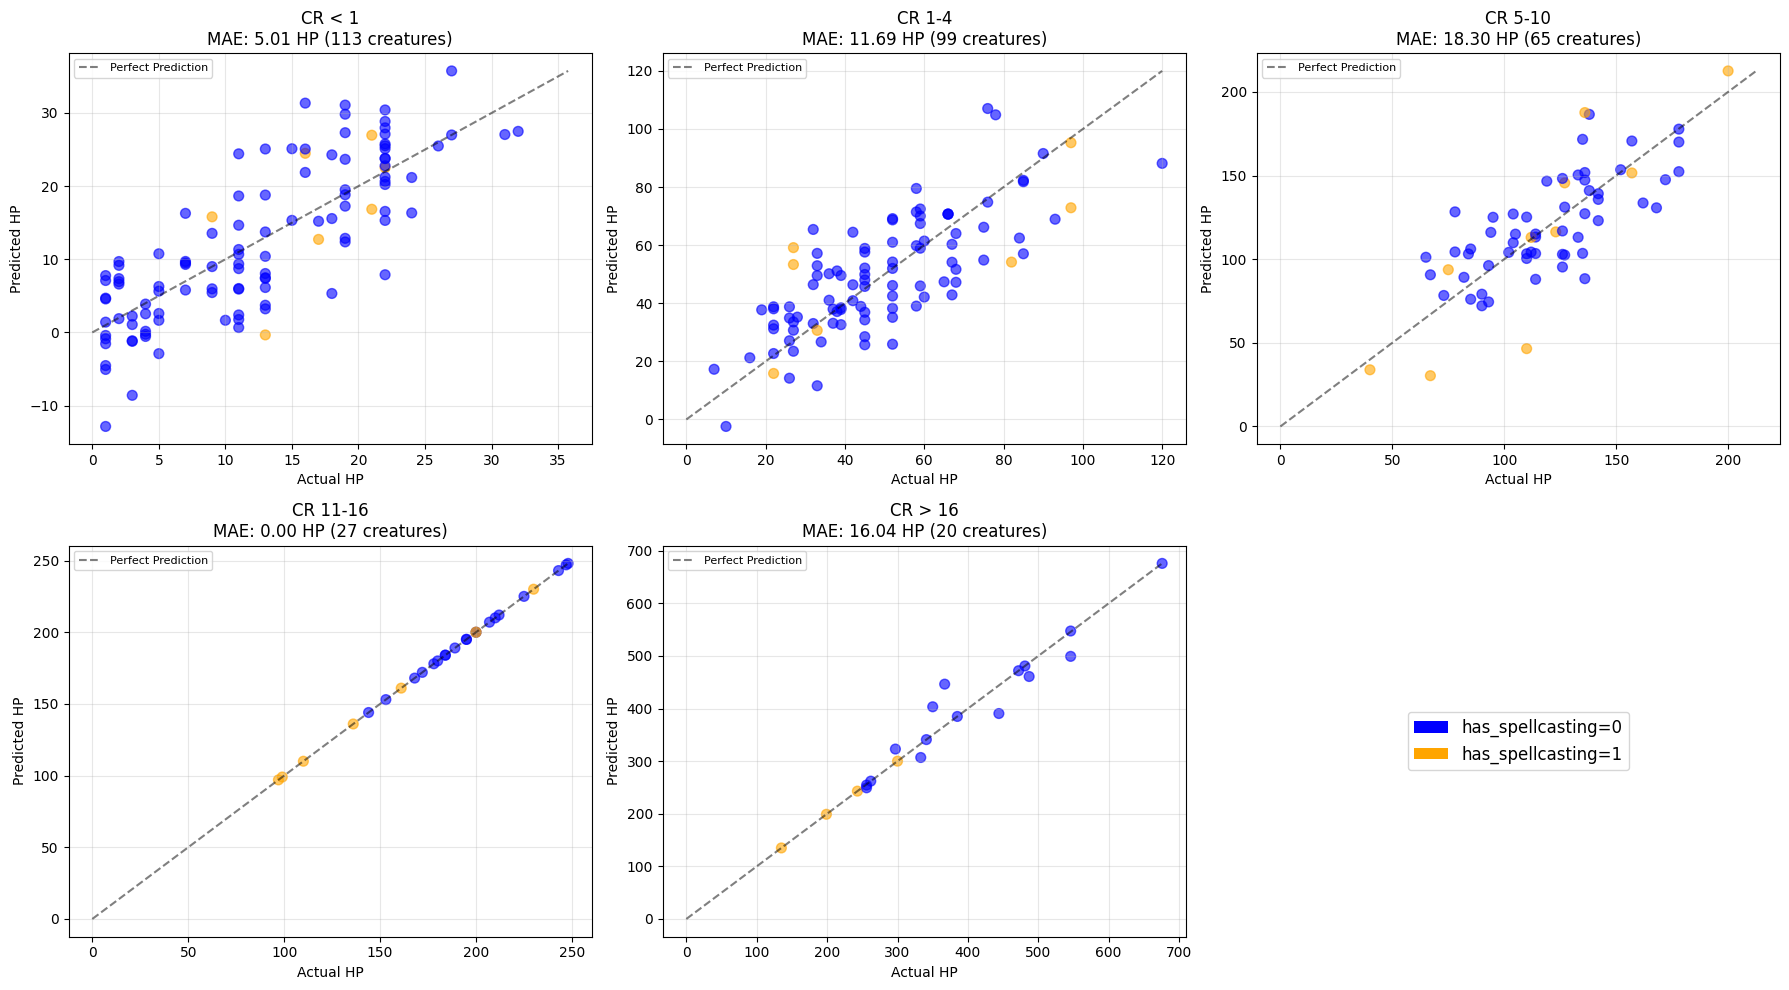

In [16]:
plot_performance_scatter(analysis_dfs, highlight_feature='has_spellcasting')


📊 VISUALIZATION: Error Distribution (5 CR Buckets)


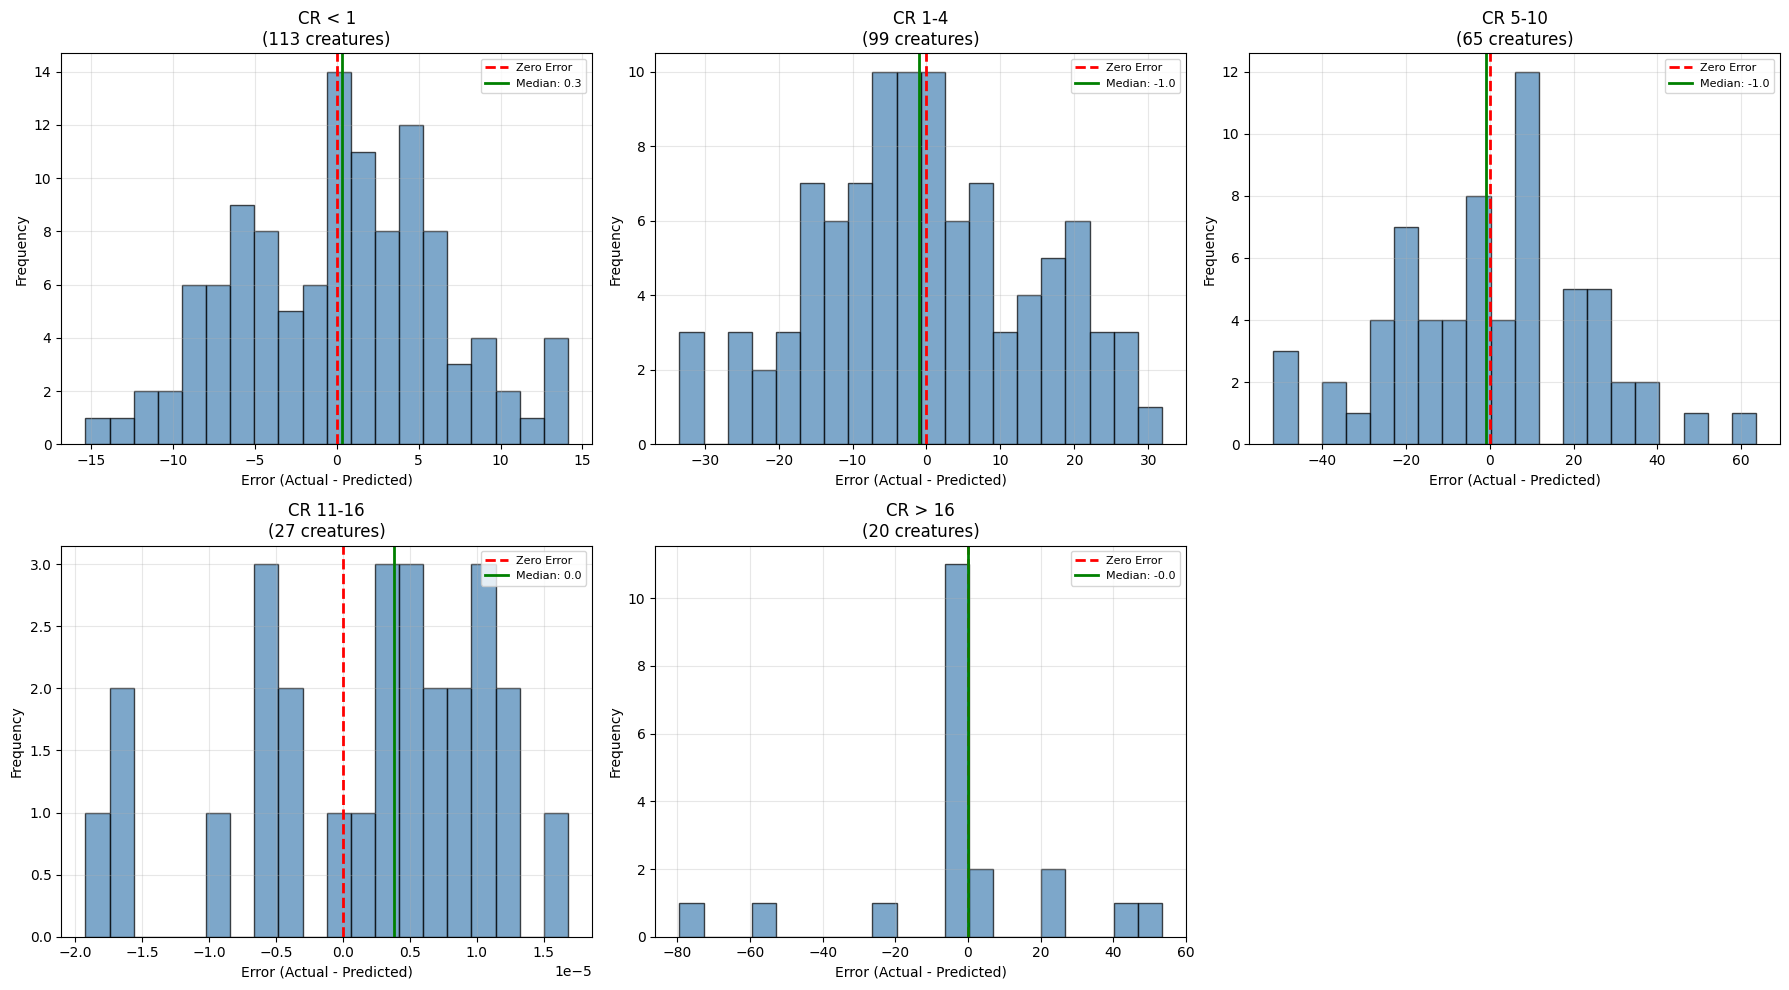

In [17]:
plot_error_hist(analysis_dfs)